# Lab 1: Evaluation of IR Systems — Precision, Recall, and F1-score

**Course:** Information Retrieval  
**Topic:** Evaluation of IR Systems (Unit 4.1)  
**Duration:** ~1.5 Hours

---

## Learning Objectives

By the end of this lab, students will be able to:

1. Understand the concepts of **relevant** and **retrieved** documents in an IR system.
2. Compute **Precision**, **Recall**, and **F1-score** manually and programmatically.
3. Visualize the **Precision–Recall trade-off** using a small toy corpus.
4. Build a simple retrieval system using TF–IDF and evaluate it against a ground truth.
5. Interpret the meaning of evaluation scores in real-world IR scenarios.

---

## Background

When an IR system processes a query, it returns a set of documents it considers relevant. To measure how good this retrieval is, we compare the system's output against a **ground truth** (the actual relevant set, as judged by humans).

Four key quantities define every evaluation:

| Symbol | Meaning |
|--------|---------|
| TP (True Positive) | Retrieved AND relevant |
| FP (False Positive) | Retrieved BUT not relevant |
| FN (False Negative) | Relevant BUT not retrieved |
| TN (True Negative) | Not retrieved AND not relevant |

From these we derive:

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{|\text{Relevant} \cap \text{Retrieved}|}{|\text{Retrieved}|}$$

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{|\text{Relevant} \cap \text{Retrieved}|}{|\text{Relevant}|}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Intuition:** Precision asks *"Of what I retrieved, how much is good?"*  
Recall asks *"Of all the good stuff, how much did I find?"*  
F1 is the harmonic mean — it punishes systems that ignore one metric for the other.

## Setup

We will use only standard libraries plus `scikit-learn`, `numpy`, `pandas`, and `matplotlib`. Install them if missing.

In [1]:
# If you are running this for the first time, uncomment the line below
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print("Environment ready.")

Environment ready.


## Part 1 — Working Through a Toy Example by Hand

Imagine a small library of 10 documents. A user issues the query **"machine learning"**. The ground truth (judged by an expert) marks 4 of these as truly relevant.

Suppose the system returns 5 documents — but only 3 of them are actually relevant.

Let's encode this and compute the three metrics step by step.

In [2]:
# Total document collection: D1..D10
all_docs = {f"D{i}" for i in range(1, 11)}

# Ground truth: documents that ARE relevant to the query
relevant = {"D1", "D2", "D5", "D8"}

# What our IR system returned for the query
retrieved = {"D1", "D2", "D3", "D5", "D9"}

print("All documents :", sorted(all_docs))
print("Relevant set  :", sorted(relevant))
print("Retrieved set :", sorted(retrieved))

All documents : ['D1', 'D10', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9']
Relevant set  : ['D1', 'D2', 'D5', 'D8']
Retrieved set : ['D1', 'D2', 'D3', 'D5', 'D9']


In [ ]:
# Compute the confusion-matrix style quantities
tp = relevant & retrieved              # retrieved AND relevant
fp = retrieved - relevant              # retrieved BUT not relevant
fn = relevant - retrieved              # relevant BUT not retrieved
tn = all_docs - relevant - retrieved   # not retrieved AND not relevant

print(f"TP = {sorted(tp)}  (count = {len(tp)})")
print(f"FP = {sorted(fp)}  (count = {len(fp)})")
print(f"FN = {sorted(fn)}  (count = {len(fn)})")
print(f"TN = {sorted(tn)}  (count = {len(tn)})")

TP = ['D1', 'D2', 'D5']  (count = 3)
FP = ['D3', 'D9']  (count = 2)
FN = ['D8']  (count = 1)
TN = ['D10', 'D4', 'D6', 'D7']  (count = 4)


In [ ]:
# Now plug into the formulas
precision = len(tp) / len(retrieved) if retrieved else 0.0
recall    = len(tp) / len(relevant)  if relevant  else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

print(f"Precision = {len(tp)}/{len(retrieved)} = {precision:.3f}")
print(f"Recall    = {len(tp)}/{len(relevant)} = {recall:.3f}")
print(f"F1-score  = {f1:.3f}")

Precision = 3/5 = 0.600
Recall    = 3/4 = 0.750
F1-score  = 0.667


### Interpretation

- **Precision = 0.60** → 60% of what we returned was actually relevant. The other 40% is noise the user has to filter out.
- **Recall = 0.75** → We found 75% of the truly relevant documents, but missed one (D8).
- **F1 = 0.67** → A balanced view; the system is decent but neither precision nor recall is excellent.

**Question to think about:** Would a search engine prefer high precision or high recall? What about a legal discovery system?

## Part 2 — Generalised Functions

Let's turn the above into reusable functions so we can evaluate any retrieval result.

In [ ]:
def precision_score(relevant, retrieved):
    """Fraction of retrieved documents that are relevant."""
    relevant, retrieved = set(relevant), set(retrieved)
    if not retrieved:
        return 0.0
    return len(relevant & retrieved) / len(retrieved)

def recall_score(relevant, retrieved):
    """Fraction of relevant documents that were retrieved."""
    relevant, retrieved = set(relevant), set(retrieved)
    if not relevant:
        return 0.0
    return len(relevant & retrieved) / len(relevant)

def f1_score(relevant, retrieved):
    """Harmonic mean of precision and recall."""
    p = precision_score(relevant, retrieved)
    r = recall_score(relevant, retrieved)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

# Quick sanity check using our toy example
print(f"P = {precision_score(relevant, retrieved):.3f}")
print(f"R = {recall_score(relevant, retrieved):.3f}")
print(f"F1 = {f1_score(relevant, retrieved):.3f}")

P = 0.600
R = 0.750
F1 = 0.667


## Part 3 — Comparing Three Different IR Systems

Suppose three different retrieval algorithms each return a set of documents for the same query. We'll judge them on the same ground truth.

In [ ]:
ground_truth = {"D1", "D2", "D5", "D8"}

systems = {
    "System A (greedy — returns many docs)":  {"D1", "D2", "D3", "D4", "D5", "D6", "D8", "D9"},
    "System B (conservative — returns few)":  {"D1", "D2"},
    "System C (balanced)":                     {"D1", "D2", "D5", "D7"},
}

rows = []
for name, retrieved in systems.items():
    rows.append({
        "System":    name,
        "Retrieved": len(retrieved),
        "Precision": round(precision_score(ground_truth, retrieved), 3),
        "Recall":    round(recall_score(ground_truth, retrieved), 3),
        "F1":        round(f1_score(ground_truth, retrieved), 3),
    })

df = pd.DataFrame(rows)
df

,System,Retrieved,Precision,Recall,F1
0,System A (greedy — returns many docs),8,0.50,1.00,0.667
1,System B (conservative — returns few),2,1.00,0.50,0.667
2,System C (balanced),4,0.75,0.75,0.750


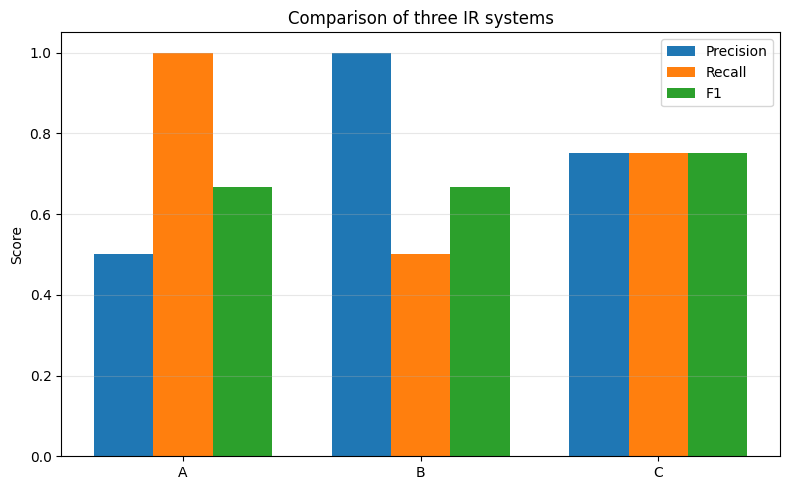

In [ ]:
# Visualise the comparison
fig, ax = plt.subplots()
x = np.arange(len(df))
width = 0.25

ax.bar(x - width, df['Precision'], width, label='Precision')
ax.bar(x,         df['Recall'],    width, label='Recall')
ax.bar(x + width, df['F1'],        width, label='F1')

ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparison of three IR systems')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- **System A** has the highest recall (it returns almost everything, so it doesn't miss much) but low precision (lots of irrelevant noise).
- **System B** is the opposite — only 2 documents returned, both relevant → perfect precision but terrible recall.
- **System C** balances both — that's why F1 favours it.

F1 captures the trade-off that neither precision nor recall alone can show.

## Part 4 — Building a Real Retrieval System with TF–IDF

Time for a more realistic exercise. We'll build a tiny search engine over a corpus of short documents, run a query, and evaluate the top-k results.

In [ ]:
corpus = [
    "Information retrieval is the science of searching for documents.",          # D0
    "Machine learning models help rank search results effectively.",              # D1
    "The capital of Nepal is Kathmandu, a city of temples.",                      # D2
    "Deep learning is a subfield of machine learning using neural networks.",     # D3
    "Search engines use inverted indices to retrieve documents quickly.",         # D4
    "Python is widely used for data science and machine learning tasks.",         # D5
    "Mount Everest lies in the Himalayan range in Nepal.",                        # D6
    "Natural language processing helps machines understand human language.",      # D7
    "Boolean retrieval was one of the earliest IR models used in libraries.",     # D8
    "Neural information retrieval combines deep learning with IR techniques.",    # D9
]

doc_ids = [f"D{i}" for i in range(len(corpus))]

for did, text in zip(doc_ids, corpus):
    print(f"{did}: {text}")

D0: Information retrieval is the science of searching for documents.
D1: Machine learning models help rank search results effectively.
D2: The capital of Nepal is Kathmandu, a city of temples.
D3: Deep learning is a subfield of machine learning using neural networks.
D4: Search engines use inverted indices to retrieve documents quickly.
D5: Python is widely used for data science and machine learning tasks.
D6: Mount Everest lies in the Himalayan range in Nepal.
D7: Natural language processing helps machines understand human language.
D8: Boolean retrieval was one of the earliest IR models used in libraries.
D9: Neural information retrieval combines deep learning with IR techniques.


In [ ]:
# Build the TF-IDF index
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
doc_vectors = vectorizer.fit_transform(corpus)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Document matrix shape:", doc_vectors.shape)

Vocabulary size: 52
Document matrix shape: (10, 52)


In [ ]:
def search(query, top_k=5):
    """Return the top_k document IDs ranked by cosine similarity to the query."""
    qv = vectorizer.transform([query])
    sims = cosine_similarity(qv, doc_vectors).flatten()
    order = np.argsort(-sims)              # descending
    results = [(doc_ids[i], sims[i]) for i in order[:top_k]]
    return results

query = "machine learning"
results = search(query, top_k=5)

print(f"Query: '{query}'\n")
print("Rank | Doc | Score | Content")
print("-" * 80)
for rank, (did, score) in enumerate(results, 1):
    snippet = corpus[int(did[1:])][:60]
    print(f"{rank:>4} | {did:>3} | {score:.3f} | {snippet}...")

Query: 'machine learning'

Rank | Doc | Score | Content
--------------------------------------------------------------------------------
   1 |  D3 | 0.552 | Deep learning is a subfield of machine learning using neural...
   2 |  D1 | 0.392 | Machine learning models help rank search results effectively...
   3 |  D5 | 0.392 | Python is widely used for data science and machine learning ...
   4 |  D9 | 0.181 | Neural information retrieval combines deep learning with IR ...
   5 |  D2 | 0.000 | The capital of Nepal is Kathmandu, a city of temples....


In [ ]:
# Ground truth for the query "machine learning"
# (Documents that genuinely talk about ML topics)
ground_truth_ml = {"D1", "D3", "D5", "D9"}

# Retrieve and evaluate the top 5
retrieved_ml = {did for did, _ in search(query, top_k=5)}

print("Relevant      :", sorted(ground_truth_ml))
print("Retrieved (top5):", sorted(retrieved_ml))
print()
print(f"Precision@5 = {precision_score(ground_truth_ml, retrieved_ml):.3f}")
print(f"Recall@5    = {recall_score(ground_truth_ml, retrieved_ml):.3f}")
print(f"F1@5        = {f1_score(ground_truth_ml, retrieved_ml):.3f}")

Relevant      : ['D1', 'D3', 'D5', 'D9']
Retrieved (top5): ['D1', 'D2', 'D3', 'D5', 'D9']

Precision@5 = 0.800
Recall@5    = 1.000
F1@5        = 0.889


## Part 5 — How k Affects Precision and Recall

A retrieval system normally returns a ranked list. We can choose to cut off at different ranks (top-1, top-3, top-5, ...). This cutoff changes the precision and recall.

Let's plot Precision@k and Recall@k for k = 1 … 10.

In [ ]:
ks = list(range(1, len(corpus) + 1))
precisions, recalls, f1s = [], [], []

ranked = [did for did, _ in search(query, top_k=len(corpus))]

for k in ks:
    topk = set(ranked[:k])
    precisions.append(precision_score(ground_truth_ml, topk))
    recalls.append(recall_score(ground_truth_ml, topk))
    f1s.append(f1_score(ground_truth_ml, topk))

table = pd.DataFrame({"k": ks, "Precision@k": precisions, "Recall@k": recalls, "F1@k": f1s}).round(3)
table

,k,Precision@k,Recall@k,F1@k
0,1,1.000,0.25,0.400
1,2,1.000,0.50,0.667
2,3,1.000,0.75,0.857
3,4,1.000,1.00,1.000
4,5,0.800,1.00,0.889
5,6,0.667,1.00,0.800
6,7,0.571,1.00,0.727
7,8,0.500,1.00,0.667
8,9,0.444,1.00,0.615
9,10,0.400,1.00,0.571


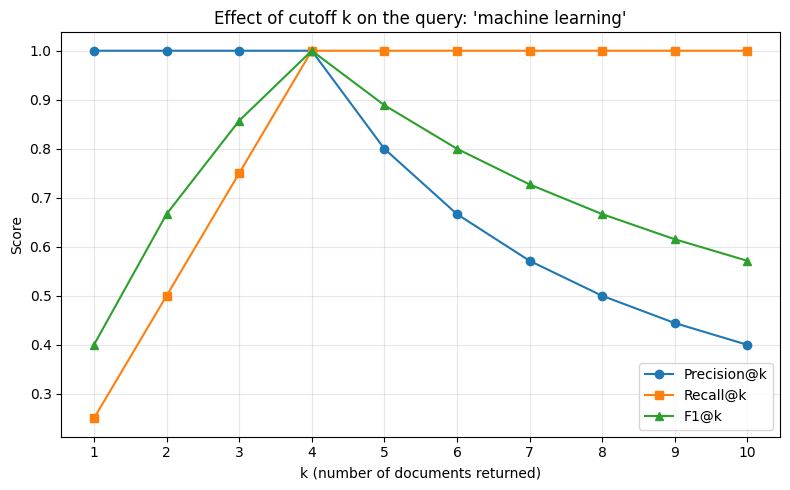

In [ ]:
plt.figure()
plt.plot(ks, precisions, 'o-', label='Precision@k')
plt.plot(ks, recalls,    's-', label='Recall@k')
plt.plot(ks, f1s,        '^-', label='F1@k')
plt.xlabel('k (number of documents returned)')
plt.ylabel('Score')
plt.title(f"Effect of cutoff k on the query: '{query}'")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.show()

### What the graph tells us

- As **k increases**, **recall monotonically rises** (or stays flat) — we can only find more relevant docs by looking at more results.
- **Precision usually falls** as k grows, because the deeper we look, the more irrelevant material we hit.
- **F1 peaks** at some sweet spot — the k where the two curves balance.

This trade-off is fundamental to every IR system.

## Part 6 — Verifying Against scikit-learn

It's a good engineering habit to cross-check custom implementations against a trusted library.

In [ ]:
from sklearn.metrics import precision_score as sk_p, recall_score as sk_r, f1_score as sk_f1

# Convert sets to binary vectors over the universe of all docs
universe = sorted(set(doc_ids))
y_true = [1 if d in ground_truth_ml else 0 for d in universe]
y_pred = [1 if d in retrieved_ml     else 0 for d in universe]

print(f"sklearn precision = {sk_p(y_true, y_pred):.3f}")
print(f"sklearn recall    = {sk_r(y_true, y_pred):.3f}")
print(f"sklearn f1        = {sk_f1(y_true, y_pred):.3f}")
print()
print(f"our   precision = {precision_score(ground_truth_ml, retrieved_ml):.3f}")
print(f"our   recall    = {recall_score(ground_truth_ml, retrieved_ml):.3f}")
print(f"our   f1        = {f1_score(ground_truth_ml, retrieved_ml):.3f}")

sklearn precision = 0.800
sklearn recall    = 1.000
sklearn f1        = 0.889

our   precision = 0.800
our   recall    = 1.000
our   f1        = 0.889


Numbers match — our hand-rolled functions are correct.

## Exercises (To Be Submitted)

1. **Manual practice.** A query has the relevant set `{D2, D4, D7, D9, D10}` and a system retrieves `{D1, D2, D4, D6, D7, D8}`. Compute precision, recall, and F1 by hand. Verify with code.

2. **Designer's dilemma.** A library is building an academic search engine. They have two options:
   - System X: precision = 0.95, recall = 0.40
   - System Y: precision = 0.60, recall = 0.85
   
   Which would you recommend, and why? Compute F1 for both. Discuss a scenario where each would actually be the better choice.

3. **Try a new query.** Use the TF–IDF system above to search for the query **"Nepal"**. Decide what the ground truth should be (look at the corpus). Then compute Precision@3, Recall@3, and F1@3.

4. **Extension.** Add two more documents to the corpus that are NOT about machine learning but that mention the word "learning" (e.g. "learning to cook"). Re-run the query `"machine learning"` and see whether the new documents pollute the top-5 results. Report how Precision@5 changes.

5. **Reflection.** In one short paragraph, explain *why F1 uses the harmonic mean rather than the simple (arithmetic) mean of precision and recall*.

---

## Summary

| Metric | Formula | What it answers |
|--------|---------|------------------|
| Precision | TP / (TP + FP) | Of what was returned, how much is good? |
| Recall | TP / (TP + FN) | Of all the good stuff, how much did we find? |
| F1 | 2PR / (P + R) | A balanced single score |

Set-based metrics like these treat retrieval as an unordered classification problem. In **Lab 2** we'll see why that's not enough — we'll extend the picture to *ranked* retrieval using MAP and nDCG.

## Solutions to Exercises

### Exercise 1: Manual practice.

In [ ]:
relevant_ex1 = {"D2", "D4", "D7", "D9", "D10"}
retrieved_ex1 = {"D1", "D2", "D4", "D6", "D7", "D8"}

# Calculate TP, FP, FN
tp_ex1 = relevant_ex1 & retrieved_ex1
fp_ex1 = retrieved_ex1 - relevant_ex1
fn_ex1 = relevant_ex1 - retrieved_ex1

# Manual Calculation
precision_ex1 = len(tp_ex1) / len(retrieved_ex1)
recall_ex1 = len(tp_ex1) / len(relevant_ex1)
f1_ex1 = (2 * precision_ex1 * recall_ex1) / (precision_ex1 + recall_ex1)

print(f"Manual Calculation:\nPrecision = {len(tp_ex1)}/{len(retrieved_ex1)} = {precision_ex1:.3f}")
print(f"Recall = {len(tp_ex1)}/{len(relevant_ex1)} = {recall_ex1:.3f}")
print(f"F1-score = {f1_ex1:.3f}")

# Verification with code
print("\nVerification with functions:")
print(f"Precision = {precision_score(relevant_ex1, retrieved_ex1):.3f}")
print(f"Recall = {recall_score(relevant_ex1, retrieved_ex1):.3f}")
print(f"F1-score = {f1_score(relevant_ex1, retrieved_ex1):.3f}")

Manual Calculation:
Precision = 3/6 = 0.500
Recall = 3/5 = 0.600
F1-score = 0.545

Verification with functions:
Precision = 0.500
Recall = 0.600
F1-score = 0.545


### Exercise 2: Designer's dilemma.

In [ ]:
p_x, r_x = 0.95, 0.40
p_y, r_y = 0.60, 0.85

f1_x = (2 * p_x * r_x) / (p_x + r_x)
f1_y = (2 * p_y * r_y) / (p_y + r_y)

print(f"System X: Precision={p_x}, Recall={r_x}, F1-score={f1_x:.3f}")
print(f"System Y: Precision={p_y}, Recall={r_y}, F1-score={f1_y:.3f}")

System X: Precision=0.95, Recall=0.4, F1-score=0.563
System Y: Precision=0.6, Recall=0.85, F1-score=0.703


Based on the F1-scores, **System Y (F1=0.706)** is generally preferable to **System X (F1=0.561)** because F1-score provides a balanced measure of both precision and recall. System Y achieves a better balance between finding relevant documents and not returning too many irrelevant ones.

**Scenario where System X would be better:**
System X, with its very high precision (0.95), would be better for tasks where false positives are extremely costly or annoying, and users prefer not to sift through irrelevant results. For an academic search engine, this might be a scenario where a researcher is looking for highly specific, critical papers, and they have very little time to review results. They would rather get a small set of perfectly relevant papers than a larger set with many irrelevant ones.

**Scenario where System Y would be better:**
System Y, with its high recall (0.85), would be better for tasks where missing relevant documents (false negatives) is more detrimental. For the same academic search engine, this could be a comprehensive literature review where the goal is to find *all* potentially relevant papers, even if it means reviewing some less relevant ones. Missing a key paper could invalidate the entire review, making high recall paramount.

### Exercise 3: Try a new query.

In [ ]:
query_nepal = "Nepal"

# Ground truth for "Nepal" (D2, D6)
ground_truth_nepal = {"D2", "D6"}

# Retrieve top 3 documents
results_nepal = search(query_nepal, top_k=3)
retrieved_nepal = {did for did, _ in results_nepal}

print(f"Query: '{query_nepal}'")
print("Relevant documents (ground truth):", sorted(ground_truth_nepal))
print("Retrieved documents (top 3):", sorted(retrieved_nepal))

precision_at_3 = precision_score(ground_truth_nepal, retrieved_nepal)
recall_at_3 = recall_score(ground_truth_nepal, retrieved_nepal)
f1_at_3 = f1_score(ground_truth_nepal, retrieved_nepal)

print(f"\nPrecision@3 = {precision_at_3:.3f}")
print(f"Recall@3    = {recall_at_3:.3f}")
print(f"F1@3        = {f1_at_3:.3f}")

Query: 'Nepal'
Relevant documents (ground truth): ['D2', 'D6']
Retrieved documents (top 3): ['D1', 'D2', 'D6']

Precision@3 = 0.667
Recall@3    = 1.000
F1@3        = 0.800


### Exercise 4: Extension.

In [ ]:
# Add two new documents to the corpus
new_corpus = corpus + [
    "I enjoy learning to cook new recipes every week.", # D10
    "The student is learning about historical events.", # D11
]

new_doc_ids = [f"D{i}" for i in range(len(new_corpus))]

print("New Corpus with Added Documents:")
for did, text in zip(new_doc_ids, new_corpus):
    print(f"{did}: {text}")

# Rebuild the TF-IDF index with the new corpus
new_vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
new_doc_vectors = new_vectorizer.fit_transform(new_corpus)

# Update the search function to use the new vectorizer and doc_ids
def search_new_corpus(query, top_k=5):
    qv = new_vectorizer.transform([query])
    sims = cosine_similarity(qv, new_doc_vectors).flatten()
    order = np.argsort(-sims)
    results = [(new_doc_ids[i], sims[i]) for i in order[:top_k]]
    return results

# Re-run the query "machine learning"
query_ml_extended = "machine learning"

# Ground truth for the query "machine learning" (remains the same as D1, D3, D5, D9)
ground_truth_ml_extended = {"D1", "D3", "D5", "D9"}

# Retrieve and evaluate the top 5 with the extended corpus
retrieved_ml_extended = {did for did, _ in search_new_corpus(query_ml_extended, top_k=5)}

print(f"\nQuery: '{query_ml_extended}'")
print("Relevant      :", sorted(ground_truth_ml_extended))
print("Retrieved (top5) with extended corpus:", sorted(retrieved_ml_extended))

precision_at_5_extended = precision_score(ground_truth_ml_extended, retrieved_ml_extended)
recall_at_5_extended = recall_score(ground_truth_ml_extended, retrieved_ml_extended)
f1_at_5_extended = f1_score(ground_truth_ml_extended, retrieved_ml_extended)

print(f"\nPrecision@5 (original) = {precision_score(ground_truth_ml, retrieved_ml):.3f}")
print(f"Precision@5 (extended) = {precision_at_5_extended:.3f}")
print(f"Recall@5 (extended)    = {recall_at_5_extended:.3f}")
print(f"F1@5 (extended)        = {f1_at_5_extended:.3f}")

# Check for pollution
polluted = not retrieved_ml_extended.issubset(ground_truth_ml_extended)
if polluted:
    print(f"\nNew documents polluted the top-5 results. Irrelevant documents: {retrieved_ml_extended - ground_truth_ml_extended}")
else:
    print("\nNew documents did not pollute the top-5 results (no change in retrieved docs).")

New Corpus with Added Documents:
D0: Information retrieval is the science of searching for documents.
D1: Machine learning models help rank search results effectively.
D2: The capital of Nepal is Kathmandu, a city of temples.
D3: Deep learning is a subfield of machine learning using neural networks.
D4: Search engines use inverted indices to retrieve documents quickly.
D5: Python is widely used for data science and machine learning tasks.
D6: Mount Everest lies in the Himalayan range in Nepal.
D7: Natural language processing helps machines understand human language.
D8: Boolean retrieval was one of the earliest IR models used in libraries.
D9: Neural information retrieval combines deep learning with IR techniques.
D10: I enjoy learning to cook new recipes every week.
D11: The student is learning about historical events.

Query: 'machine learning'
Relevant      : ['D1', 'D3', 'D5', 'D9']
Retrieved (top5) with extended corpus: ['D1', 'D10', 'D11', 'D3', 'D5']

Precision@5 (original) = 0.

### Exercise 5: Reflection.

F1-score uses the harmonic mean rather than the simple arithmetic mean of precision and recall because the harmonic mean is more sensitive to lower values. This means that if either precision or recall is very low, the F1-score will also be low, effectively penalizing systems that perform well on one metric but poorly on the other. The arithmetic mean, on the other hand, would be less sensitive to such imbalances, potentially giving a misleadingly high score if one metric is excellent while the other is abysmal. The harmonic mean thus provides a more realistic and conservative measure of a system's overall effectiveness when both metrics are important and need to be balanced.